# 10 · Inventario multianual RAMA 2020–2026 y cobertura de estaciones

Este libro trata **sólo de los datos crudos**: qué archivos llegaron, si su
formato es el mismo que el de 2025, cuánto `-99` traen, qué estaciones
operaron cada año, dónde están geográficamente y qué periodos tienen
contingencias (≥155 ppb). Es el equivalente multianual del
[notebook 01](01_inspeccion_rama.ipynb).

**Qué NO hace:** no entrena, no carga ningún modelo, no evalúa el LSTM y no
interpola. Los faltantes se conservan como ausencia (D8). Las coordenadas de
las estaciones son sólo para nosotros: **no forman parte de la entrada del LSTM.**

**Fuentes:** `data/raw/20RAMA.zip` … `26RAMA.zip` (se leen directamente del zip,
sin extraer) y el catálogo oficial de estaciones del SIMAT guardado en
`data/reference/cat_estacion_simat.csv`.

**Salidas:**

| Ruta | Contenido | Versionado |
|---|---|---|
| `docs/checksums_2020_2026.txt` | SHA-256 de zips y de cada `.xls` interno | sí |
| `results/inventario_multianual/*.csv` | tablas de inventario, cobertura, rachas, excedencias | sí |
| `docs/img/inventario_multianual/*.png` | figuras nuevas (carpeta nueva, no sobrescribe nada) | sí |
| `data/processed/o3_2020_2026_*.parquet` | O₃ preparado, largo y ancho, faltantes como NaN | no (`data/` ignorado) |

In [1]:
import hashlib, io, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path('..').resolve()
RAW = RAIZ / 'data/raw'
SAL = RAIZ / 'results/inventario_multianual'
IMG = RAIZ / 'docs/img/inventario_multianual'
PROC = RAIZ / 'data/processed'
for d in (SAL, IMG, PROC):
    d.mkdir(parents=True, exist_ok=True)

ANIOS = list(range(2020, 2027))
CONTAMINANTES = ['O3', 'NO2', 'NO', 'NOX', 'CO', 'SO2', 'PM10', 'PM25', 'PMCO']
CENTINELA = -99
UMBRAL_CONTINGENCIA = 155          # ppb, PICA Fase 1 (CLAUDE.md: siempre 155)
BANDAS_O3 = [58, 90, 135, 175]     # NOM-172-2023, Tabla 6
NOMBRES_BANDA = ['Buena', 'Aceptable', 'Mala', 'Muy Mala', 'Ext. Mala']

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

## 1. Qué archivos llegaron

Cada zip debería traer los mismos 9 contaminantes de un año. Calculo el SHA-256
del zip y de cada `.xls` interno para que cualquiera pueda confirmar que trabaja
sobre los mismos bytes, como en `docs/checksums_2025.txt`.

In [2]:
def sha256(b):
    return hashlib.sha256(b).hexdigest()

archivos, crudos = [], {}
for anio in ANIOS:
    z = RAW / f'{str(anio)[2:]}RAMA.zip'
    with zipfile.ZipFile(z) as zf:
        for info in zf.infolist():
            b = zf.read(info)
            cont = info.filename[4:-4]
            crudos[(anio, cont)] = b
            archivos.append(dict(anio=anio, zip=z.name, sha256_zip=sha256(z.read_bytes()),
                                 archivo=info.filename, contaminante=cont,
                                 bytes=info.file_size,
                                 fecha_en_zip=pd.Timestamp(*info.date_time),
                                 sha256=sha256(b)))
archivos = pd.DataFrame(archivos).sort_values(['anio', 'contaminante']).reset_index(drop=True)

print(archivos.pivot(index='contaminante', columns='anio', values='bytes').to_string())
faltan = {a: sorted(set(CONTAMINANTES) - set(archivos.query('anio == @a').contaminante)) for a in ANIOS}
print('\nContaminantes faltantes por año:', {a: f for a, f in faltan.items() if f} or 'ninguno')

anio             2020     2021     2022     2023     2024     2025     2026
contaminante                                                               
CO            2151424  2545664  2618880  2557440  2575872  2586112  1509376
NO            2223616  2270720  2270720  2059264  2305536  2057216  1204736
NO2           2276864  2323968  2323968  2217984  2352640  2321920  1358336
NOX           2223616  2270720  2270720  2059264  2288640  2268672  1327616
O3            2330112  2323968  2323968  2217984  2328064  2321920  1358336
PM10          1852416  1900032  1900032  1794048  1903104  1792000  1050624
PM25          1692672  1688064  1688064  1582080  1690112  1580032   927232
PMCO          1320960  1317376  1317376  1211392  1318400  1209344   711680
SO2           2170880  2165248  2165248  2112000  2191872  2162688  1266176

Contaminantes faltantes por año: ninguno


In [3]:
# Fecha de modificación dentro del zip: detecta archivos sustituidos después de la publicación.
fechas = archivos.pivot(index='contaminante', columns='anio', values='fecha_en_zip')
print(fechas.apply(lambda c: c.dt.strftime('%Y-%m-%d')).to_string())

# El zip de 2025 debe coincidir byte a byte con los .xls que ya usaba el proyecto.
ref = dict(l.split()[::-1] for l in (RAIZ / 'docs/checksums_2025.txt').read_text().splitlines() if l.strip())
c25 = archivos.query('anio == 2025')
print('\n25RAMA.zip == checksums_2025.txt:', all(ref[r.archivo] == r.sha256 for r in c25.itertuples()))

lineas = [f'# SHA-256 de los zips RAMA/SIMAT y de cada .xls interno (generado por notebooks/10).']
for z, h in archivos.drop_duplicates('zip')[['zip', 'sha256_zip']].itertuples(index=False):
    lineas.append(f'{h}  {z}')
lineas += [f'{r.sha256}  {r.zip}:{r.archivo}' for r in archivos.itertuples()]
(RAIZ / 'docs/checksums_2020_2026.txt').write_text('\n'.join(lineas) + '\n')
archivos.drop(columns='sha256_zip').to_csv(SAL / 'archivos.csv', index=False)

anio                2020        2021        2022        2023        2024        2025        2026
contaminante                                                                                    
CO            2021-08-02  2022-06-02  2023-04-13  2024-04-29  2026-03-20  2026-01-27  2026-08-25
NO            2021-08-02  2022-06-02  2023-04-13  2024-04-29  2026-03-20  2026-05-13  2026-08-25
NO2           2021-08-02  2022-06-02  2023-04-13  2024-04-29  2026-03-20  2026-01-27  2026-08-25
NOX           2021-08-02  2022-06-02  2023-04-13  2024-04-29  2026-03-20  2026-05-13  2026-08-25
O3            2021-08-02  2022-06-02  2023-04-13  2024-04-29  2026-03-20  2026-01-27  2026-08-25
PM10          2021-08-02  2022-06-02  2023-04-13  2024-11-27  2026-03-20  2026-01-27  2026-08-25
PM25          2021-08-02  2022-06-02  2023-04-13  2024-04-29  2026-03-20  2026-05-13  2026-08-25
PMCO          2021-08-02  2022-06-02  2023-04-13  2024-04-29  2026-03-20  2026-01-27  2026-08-25
SO2           2021-08-02  2022

## 2. ¿El formato es el mismo que en 2025?

En 2025 el formato era `FECHA | HORA | estaciones…`, con `HORA` de 1 a 24 y
`-99` como faltante (ver `src/ingest/rama.py`). El pendiente **V5** del
repositorio pedía verificar si esto se mantiene en años anteriores. Reviso, por
archivo, el encabezado, el número de filas frente a las horas esperadas, los
duplicados, el rango de `HORA`, si hay decimales y si aparecen negativos
distintos de `-99`.

In [4]:
def leer(anio, cont):
    return pd.read_excel(io.BytesIO(crudos[(anio, cont)]), header=0)

def horas_esperadas(anio):
    fin = pd.Timestamp(f'{anio}-12-31 23:00')
    if anio == 2026:            # año en curso: se compara contra el último día publicado
        fin = None
    return fin

tablas, formato = {}, []
for (anio, cont) in sorted(crudos):
    df = leer(anio, cont)
    tablas[(anio, cont)] = df
    est = [c for c in df.columns if c not in ('FECHA', 'HORA')]
    v = df[est].to_numpy(float).ravel()
    ts = df['FECHA'] + pd.to_timedelta(df['HORA'] - 1, unit='h')
    fin = horas_esperadas(anio) or ts.max().normalize() + pd.Timedelta(hours=23)
    rejilla = pd.date_range(f'{anio}-01-01', fin, freq='h')
    otros_neg = v[(v < 0) & (v != CENTINELA)]
    formato.append(dict(
        anio=anio, contaminante=cont,
        encabezado_ok=list(df.columns[:2]) == ['FECHA', 'HORA'],
        n_estaciones=len(est), filas=len(df), horas_esperadas=len(rejilla),
        filas_faltantes=len(rejilla.difference(ts)), duplicados=int(ts.duplicated().sum()),
        hora_min=int(df.HORA.min()), hora_max=int(df.HORA.max()),
        desde=ts.min().date(), hasta=ts.max().date(),
        pct_centinela=round(100 * np.mean(v == CENTINELA), 2),
        nan_reales=int(np.isnan(v).sum()),
        con_decimales=bool((~np.isclose(v, np.round(v))).any()),
        otros_negativos=len(otros_neg),
        valores_otros_neg=sorted(set(np.round(otros_neg, 2)))[:6],
        maximo=np.nanmax(v)))
formato = pd.DataFrame(formato)
formato.to_csv(SAL / 'formato_por_archivo.csv', index=False)

print('Encabezado FECHA|HORA en todos:', formato.encabezado_ok.all())
print('HORA siempre 1..24:', ((formato.hora_min == 1) & (formato.hora_max == 24)).all())
print('Duplicados FECHA+HORA:', formato.duplicados.sum(), '| NaN reales (no -99):', formato.nan_reales.sum())
print('\nArchivos con filas (horas) ausentes:')
print(formato.query('filas_faltantes > 0')[['anio', 'contaminante', 'filas', 'horas_esperadas', 'filas_faltantes']].to_string(index=False))
print('\nCobertura temporal de 2026:', formato.query('anio == 2026')[['desde', 'hasta']].drop_duplicates().to_string(index=False))

Encabezado FECHA|HORA en todos: True
HORA siempre 1..24: True
Duplicados FECHA+HORA: 0 | NaN reales (no -99): 0

Archivos con filas (horas) ausentes:
 anio contaminante  filas  horas_esperadas  filas_faltantes
 2024           CO   8782             8784                2
 2024           NO   8782             8784                2
 2024          NO2   8782             8784                2
 2024          NOX   8782             8784                2
 2024           O3   8782             8784                2
 2024         PM10   8782             8784                2
 2024         PM25   8782             8784                2
 2024         PMCO   8782             8784                2
 2024          SO2   8782             8784                2

Cobertura temporal de 2026:      desde      hasta
2026-01-01 2026-07-31


In [5]:
# ¿Qué horas faltan como fila? (distinto de una celda con -99: aquí no existe el renglón)
for (anio, cont), df in tablas.items():
    if cont != 'O3':
        continue
    ts = df['FECHA'] + pd.to_timedelta(df['HORA'] - 1, unit='h')
    rej = pd.date_range(f'{anio}-01-01', ts.max().normalize() + pd.Timedelta(hours=23), freq='h')
    hueco = rej.difference(ts)
    if len(hueco):
        print(anio, cont, 'renglones ausentes:', [str(t) for t in hueco])

2024 O3 renglones ausentes: ['2024-01-17 18:00:00', '2024-04-06 23:00:00']


In [6]:
print('Archivos con decimales:', sorted(formato.query('con_decimales').contaminante.unique()))
print('\nNegativos distintos de -99:')
print(formato.query('otros_negativos > 0')[['anio', 'contaminante', 'otros_negativos', 'valores_otros_neg']].to_string(index=False))
print('\nMáximo por contaminante y año:')
print(formato.pivot(index='contaminante', columns='anio', values='maximo').to_string())

Archivos con decimales: ['CO']

Negativos distintos de -99:
 anio contaminante  otros_negativos            valores_otros_neg
 2021           CO                3                      [-0.01]
 2023           CO               13 [-0.04, -0.03, -0.02, -0.01]
 2026           NO                2                       [-1.0]
 2026          SO2                1                       [-1.0]

Máximo por contaminante y año:
anio           2020    2021    2022    2023    2024    2025    2026
contaminante                                                       
CO              4.6    4.51    4.49    4.95    5.44    6.09    5.16
NO            456.0  431.00  396.00  439.00  498.00  525.00  423.00
NO2           118.0  132.00  131.00  118.00  140.00  120.00  126.00
NOX           509.0  498.00  435.00  491.00  569.00  575.00  474.00
O3            159.0  160.00  172.00  171.00  187.00  168.00  168.00
PM10          615.0  982.00  773.00  629.00  582.00  442.00  652.00
PM25          189.0  256.00  210.00  26

## 3. El centinela `-99` en todos los años

En 2025 el `-99` cubría el 30.61 % de las celdas de O₃ y, sin limpiarlo, la media
caía a −7.75 ppb. Repito la cuantificación para todos los contaminantes y años.
Ojo: este porcentaje incluye columnas de estaciones que no operaron en todo el
año, así que **no es la cobertura de la red operativa** (eso va en la sección 5).

In [7]:
print(formato.pivot(index='contaminante', columns='anio', values='pct_centinela').to_string())

print('\nO3 — efecto del centinela sobre la media:')
for anio in ANIOS:
    df = tablas[(anio, 'O3')]
    v = df.drop(columns=['FECHA', 'HORA']).to_numpy(float).ravel()
    limpio = np.where(v == CENTINELA, np.nan, v)
    print(f'  {anio}: media sin limpiar {v.mean():7.2f} | limpia {np.nanmean(limpio):6.2f} ppb')

anio           2020   2021   2022   2023   2024   2025   2026
contaminante                                                 
CO            31.25  31.34  31.96  28.67  36.54  32.29  33.83
NO            44.16  46.33  44.75  39.57  47.76  39.42  37.13
NO2           36.15  38.53  36.56  35.08  42.11  40.09  39.88
NOX           44.16  46.33  44.75  39.57  47.76  46.35  44.31
O3            31.54  31.10  26.55  25.32  29.31  30.61  32.05
PM10          49.66  45.64  41.73  43.79  49.17  43.84  42.40
PM25          44.21  44.67  43.98  41.59  49.77  47.60  47.53
PMCO          51.64  52.87  53.00  50.73  52.29  50.77  52.61
SO2           31.36  34.56  31.60  33.47  36.86  33.93  38.63

O3 — efecto del centinela sobre la media:
  2020: media sin limpiar   -9.37 | limpia  31.92 ppb
  2021: media sin limpiar  -10.70 | limpia  29.16 ppb
  2022: media sin limpiar   -3.41 | limpia  31.14 ppb
  2023: media sin limpiar   -2.06 | limpia  30.81 ppb
  2024: media sin limpiar   -6.09 | limpia  32.43 ppb
  202

## 4. Preparación de O₃: rejilla horaria completa, `-99 → NaN`

Para los siguientes análisis, y para tener los datos listos cuando probemos el
LSTM, armo O₃ en una **rejilla horaria completa** por año: cada hora del año
existe una vez y cada estación es una columna. Un `-99` y un renglón ausente
quedan ambos como `NaN`, pero guardo cuál fue cuál (`origen_faltante`).

Mantengo la convención de `src/ingest/rama.to_long`: `HORA=1` → 00:00 y
`HORA=24` → 23:00 del mismo día. Es la misma que usó el LSTM en 2025; sigue sin
verificarse contra la especificación del SIMAT.

**No se interpola nada.**

In [8]:
largos = []
for anio in ANIOS:
    df = tablas[(anio, 'O3')]
    est = [c for c in df.columns if c not in ('FECHA', 'HORA')]
    l = df.melt(id_vars=['FECHA', 'HORA'], value_vars=est, var_name='station', value_name='crudo')
    l['timestamp'] = l['FECHA'] + pd.to_timedelta(l['HORA'] - 1, unit='h')
    fin = l['timestamp'].max().normalize() + pd.Timedelta(hours=23)
    rej = pd.MultiIndex.from_product([pd.date_range(f'{anio}-01-01', fin, freq='h'), est],
                                     names=['timestamp', 'station'])
    l = l.set_index(['timestamp', 'station'])[['crudo']].reindex(rej).reset_index()
    l['origen_faltante'] = np.select([l.crudo.isna(), l.crudo == CENTINELA], ['renglon_ausente', 'centinela_-99'], '')
    l['value'] = l['crudo'].where(l['crudo'] != CENTINELA)
    l['anio'] = anio
    largos.append(l)
o3 = pd.concat(largos, ignore_index=True)
o3['station'] = o3['station'].astype('category')
o3['origen_faltante'] = o3['origen_faltante'].astype('category')

print(o3.groupby('anio').agg(horas=('timestamp', 'nunique'), estaciones=('station', 'nunique'),
                             celdas=('value', 'size'), validas=('value', 'count')).to_string())
print('\nOrigen de los faltantes:')
print(o3.groupby(['anio', 'origen_faltante'], observed=True).size().unstack(fill_value=0).to_string())

      horas  estaciones  celdas  validas
anio                                    
2020   8784          36  316224   216476
2021   8760          36  315360   217276
2022   8760          36  315360   231632
2023   8760          34  297840   222427
2024   8784          36  316224   223488
2025   8760          36  315360   218823
2026   5088          36  183168   124470

Origen de los faltantes:
origen_faltante          centinela_-99  renglon_ausente
anio                                                   
2020             216476          99748                0
2021             217276          98084                0
2022             231632          83728                0
2023             222427          75413                0
2024             223488          92664               72
2025             218823          96537                0
2026             124470          58698                0


In [9]:
o3[['timestamp', 'anio', 'station', 'value', 'origen_faltante']].to_parquet(PROC / 'o3_2020_2026_largo.parquet', index=False)
ancho = o3.pivot(index='timestamp', columns='station', values='value').sort_index()
ancho.columns = ancho.columns.astype(str)
ancho.to_parquet(PROC / 'o3_2020_2026_ancho.parquet')
print('Matriz ancha:', ancho.shape, '| de', ancho.index.min(), 'a', ancho.index.max())
print('Horas faltantes en la rejilla continua:', len(pd.date_range(ancho.index.min(), ancho.index.max(), freq='h').difference(ancho.index)))

Matriz ancha: (57696, 36) | de 2020-01-01 00:00:00 a 2026-07-31 23:00:00
Horas faltantes en la rejilla continua: 0


## 5. Qué estaciones existen y cuáles operaron cada año

Hay que distinguir dos cosas que en 2025 se confundían fácilmente:

- **columna presente:** la estación aparece en el `.xls`;
- **operó:** tiene al menos una lectura válida en el año.

En 2025, COY, SFE y SJA venían como columnas llenas de `-99`, y por eso
`cargar_matriz` (con `dropna(how='all')`) dejó 33 estaciones. Si otro año tiene
un conjunto distinto, la matriz de ese año **no tendría las mismas 66
características** con las que se entrenaron los modelos de 2025. Esto es
importante para cualquier prueba del LSTM.

In [10]:
presente = o3.groupby(['station', 'anio'], observed=True).size().unstack().notna()
validas = o3.groupby(['station', 'anio'], observed=True)['value'].count().unstack()
estado = pd.DataFrame('', index=presente.index, columns=ANIOS)
estado[presente] = 'sin datos'
estado[validas > 0] = 'operó'
estado[~presente] = 'sin columna'
estado = estado.reindex(columns=ANIOS).fillna('sin columna')
print(estado.replace({'operó': '✓', 'sin datos': '·(-99)', 'sin columna': '—'}).to_string())
estado.to_csv(SAL / 'estado_estaciones_o3.csv')

EST_2025 = sorted(estado.index[estado[2025] == 'operó'])
print(f'\nEstaciones de la matriz de 2025 (las que usa el LSTM): {len(EST_2025)}')
for anio in ANIOS:
    op = set(estado.index[estado[anio] == 'operó'])
    print(f'  {anio}: operaron {len(op):2d} | de las 33 de 2025 faltan {sorted(set(EST_2025) - op)} '
          f'| nuevas fuera de las 33: {sorted(op - set(EST_2025))}')

           2020    2021    2022    2023    2024    2025    2026
station                                                        
ACO      ·(-99)       ✓       ✓       ✓  ·(-99)       ✓       ✓
AJM           ✓  ·(-99)       ✓       ✓       ✓       ✓       ✓
AJU           ✓       ✓       ✓       ✓       ✓       ✓  ·(-99)
ATI           ✓       ✓       ✓       ✓       ✓       ✓       ✓
BJU           ✓       ✓       ✓       ✓       ✓       ✓       ✓
CAM           ✓       ✓       ✓       ✓       ✓       ✓       ✓
CCA           ✓       ✓       ✓       ✓       ✓       ✓       ✓
CHO      ·(-99)       ✓       ✓       ✓       ✓       ✓  ·(-99)
COY      ·(-99)  ·(-99)  ·(-99)       —  ·(-99)  ·(-99)  ·(-99)
CUA           ✓       ✓       ✓       ✓       ✓       ✓       ✓
CUT           ✓       ✓       ✓       ✓       ✓       ✓       ✓
FAC           ✓       ✓       ✓       ✓       ✓       ✓       ✓
FAR           ✓       ✓       ✓       ✓       ✓       ✓  ·(-99)
GAM           ✓       ✓       ✓       ✓ 

In [11]:
# Mismo análisis para los demás contaminantes: número de estaciones que operaron
n_op = {}
for (anio, cont), df in tablas.items():
    est = [c for c in df.columns if c not in ('FECHA', 'HORA')]
    n_op[(cont, anio)] = int((df[est].replace(CENTINELA, np.nan).notna().any()).sum())
print('Estaciones con al menos una lectura válida:')
print(pd.Series(n_op).unstack().reindex(CONTAMINANTES).to_string())

Estaciones con al menos una lectura válida:
      2020  2021  2022  2023  2024  2025  2026
O3      31    31    32    33    32    33    30
NO2     28    28    28    29    28    29    27
NO      24    23    24    25    24    25    24
NOX     24    24    24    25    24    25    24
CO      28    27    29    30    29    30    29
SO2     29    28    28    30    29    30    28
PM10    18    22    22    23    22    23    20
PM25    17    18    18    19    18    19    15
PMCO    10    11    11    12    12    12    10


## 6. Cobertura de O₃ por estación y año

Cobertura = % de horas de la rejilla del año con lectura válida. Para 2026 la
rejilla va del 1/ene al último día publicado, no al año completo.

En 2025 vimos que **la cobertura sola es insuficiente**: CAM tenía más cobertura
que UIZ pero rachas 2.4× más largas. Por eso acompaño la cobertura con la
racha máxima de horas consecutivas sin dato.

In [12]:
def racha_max(s):
    falta = s.isna().to_numpy()
    if not falta.any():
        return 0
    bordes = np.diff(np.r_[0, falta.astype(int), 0])
    return int((np.flatnonzero(bordes == -1) - np.flatnonzero(bordes == 1)).max())

g = o3.groupby(['station', 'anio'], observed=True)
cobertura = (100 * g['value'].count() / g.size()).unstack().round(2)
rachas = o3.sort_values('timestamp').groupby(['station', 'anio'], observed=True)['value'].apply(racha_max).unstack()
cobertura.to_csv(SAL / 'cobertura_o3.csv')
rachas.to_csv(SAL / 'racha_max_o3_horas.csv')

orden = cobertura.mean(axis=1).sort_values(ascending=False).index
print('Cobertura (%):')
print(cobertura.loc[orden].to_string())

Cobertura (%):
anio      2020   2021   2022   2023   2024   2025   2026
station                                                 
CCA      95.26  89.49  95.23  93.11  92.96  96.93  92.90
MGH      88.33  96.50  94.73  89.44  93.58  90.39  95.93
FAC      95.03  90.19  89.59  93.37  86.07  86.38  92.08
MER      93.53  96.56  90.01  86.04  88.68  84.17  92.45
TLA      94.54  94.77  87.19  79.37  80.32  92.25  83.20
PED      94.97  90.13  74.11  76.92  87.91  93.12  93.22
UIZ      94.30  77.51  87.69  76.71  86.93  88.09  95.52
CUT      82.47  84.12  88.25  84.00  82.23  92.40  92.08
LPR      59.74  94.26  90.84  95.91  84.67  88.63  89.86
UAX      95.55  91.05  85.88  82.07  70.25  77.58  91.96
VIF      92.47  69.28  91.55  86.84  78.76  87.36  84.49
NEZ      95.33  80.22  89.49  85.72  81.06  73.64  84.83
ATI      92.78  88.50  85.75  56.99  78.07  86.59  90.74
BJU      93.40  91.93  86.56  91.67  72.42  54.84  86.22
CAM      94.73  94.61  75.18  72.56  72.93  90.45  65.68
SAG      86.93  

In [13]:
print('Racha máxima sin dato (días):')
print((rachas.loc[orden] / 24).round(1).to_string())

Racha máxima sin dato (días):
anio      2020   2021   2022   2023   2024   2025   2026
station                                                 
CCA        4.0   21.2    3.0   15.6    3.3    0.7    8.7
MGH       28.5    2.0    3.2   28.0    4.0    9.6    1.0
FAC        3.3   21.6    9.5    3.3   21.5   28.6    6.1
MER        5.9    0.8    6.5   15.0    8.3   42.5    3.1
TLA        2.4    1.4   21.6   42.4   43.5    5.6   24.6
PED        1.4   16.0   85.0   28.0    6.5   14.2    2.8
UIZ        3.1   37.6   21.4   33.6    6.0    8.1    2.0
CUT       42.7   18.5   22.1   31.3   32.9    7.5    2.5
LPR      137.0    7.3    9.5    0.6   34.3   30.2   13.0
UAX        3.0   14.5   23.2   26.6   46.1   36.8    8.5
VIF        6.5   96.1    9.0   33.4   40.4   20.0   15.0
NEZ        2.5   23.0   11.0   39.3   33.5   54.3   15.0
ATI        5.4   28.4   35.0  127.7   51.6   16.4   10.0
BJU        4.6   16.5   37.2   20.0   39.4   72.5   20.6
CAM        3.1    7.6   39.0   74.6   77.3   19.3   66.3
S

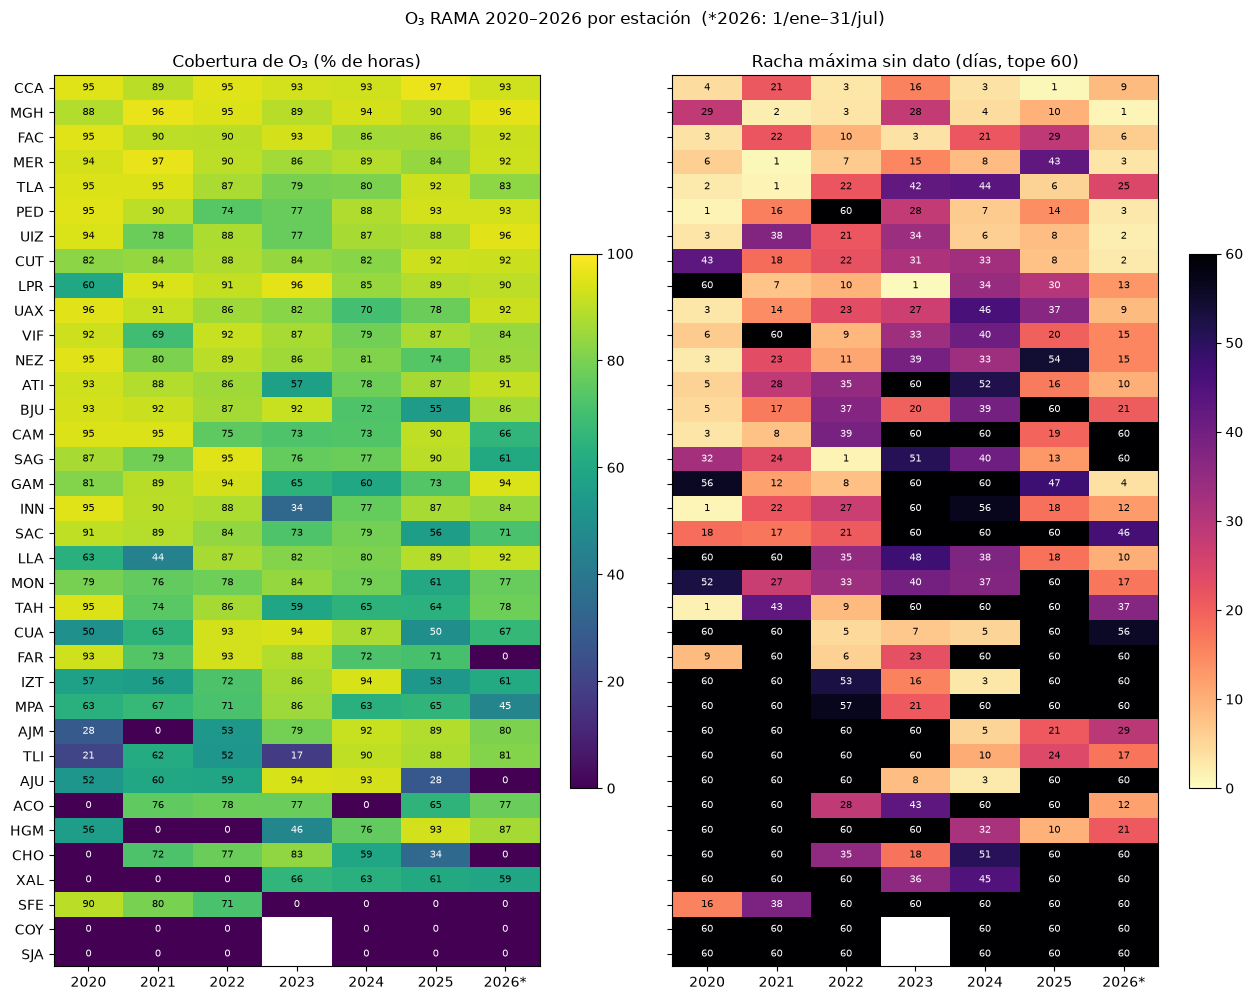

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 10), sharey=True)
for ax, (tabla, titulo, cmap, vmax) in zip(axes, [
        (cobertura.loc[orden], 'Cobertura de O₃ (% de horas)', 'viridis', 100),
        ((rachas.loc[orden] / 24).clip(upper=60), 'Racha máxima sin dato (días, tope 60)', 'magma_r', 60)]):
    im = ax.imshow(tabla.to_numpy(float), aspect='auto', cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(ANIOS)), [str(a) if a < 2026 else '2026*' for a in ANIOS])
    ax.set_yticks(range(len(orden)), orden)
    ax.set_title(titulo)
    for i in range(tabla.shape[0]):
        for j in range(tabla.shape[1]):
            x = tabla.iat[i, j]
            if pd.notna(x):
                ax.text(j, i, f'{x:.0f}', ha='center', va='center', fontsize=7,
                        color='white' if (x < vmax * 0.5) == (cmap == 'viridis') else 'black')
    fig.colorbar(im, ax=ax, shrink=0.6)
fig.suptitle('O₃ RAMA 2020–2026 por estación  (*2026: 1/ene–31/jul)', y=0.995)
fig.tight_layout()
fig.savefig(IMG / 'cobertura_rachas_o3.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.1 ¿Se repite el patrón de calibración de madrugada?

En CCA 2025, 58 de 70 bloques de faltantes medían exactamente 3 h y se
concentraban en `HORA` 1–3 (hipótesis V11: calibración programada). Reviso si
el patrón aparece en todos los años y en la red.

In [15]:
o3['HORA'] = o3['timestamp'].dt.hour + 1
fal = o3[o3.value.isna() & (o3.origen_faltante == 'centinela_-99')]
# Sólo estaciones que operaron ese año (una columna llena de -99 aplana el patrón)
op = estado.stack()
op = set(op[op == 'operó'].index)
fal = fal[[(s, a) in op for s, a in zip(fal.station, fal.anio)]]
por_hora = fal.groupby(['anio', 'HORA']).size().unstack(0)
por_hora = (100 * por_hora / por_hora.sum()).round(1)
print('% de faltantes (-99) de estaciones operativas por HORA:')
print(por_hora.to_string())

cca = o3[o3.station == 'CCA'].sort_values('timestamp')
print('\nCCA — longitud de bloques de faltantes por año:')
filas = {}
for anio, s in cca.groupby('anio'):
    falta = s.value.isna().to_numpy().astype(int)
    b = np.diff(np.r_[0, falta, 0])
    L = np.flatnonzero(b == -1) - np.flatnonzero(b == 1)
    filas[anio] = dict(bloques=len(L), de_3h=int((L == 3).sum()), max_h=int(L.max()) if len(L) else 0,
                       horas_faltantes=int(L.sum()))
print(pd.DataFrame(filas).T.to_string())

% de faltantes (-99) de estaciones operativas por HORA:
anio  2020  2021  2022  2023  2024  2025  2026
HORA                                          
1      6.3   6.2   6.6   5.8   6.2   5.7   6.3
2      6.3   6.2   6.6   5.8   6.2   5.7   6.3
3      6.3   6.2   6.6   5.8   6.2   5.7   6.3
4      3.7   3.7   3.6   3.8   3.7   3.8   3.6
5      3.6   3.7   3.6   3.8   3.6   3.8   3.6
6      3.7   3.7   3.6   3.8   3.7   3.8   3.6
7      3.7   3.7   3.7   3.8   3.7   3.8   3.7
8      3.7   3.7   3.7   3.8   3.6   3.8   3.7
9      3.7   3.8   3.8   3.8   3.6   3.8   3.7
10     3.8   3.9   3.9   3.8   3.7   3.9   3.8
11     3.9   4.0   4.1   3.9   3.8   4.0   4.0
12     4.0   4.1   4.1   4.1   4.0   4.2   4.2
13     4.0   4.1   4.1   4.3   4.1   4.3   4.4
14     3.9   4.0   4.0   4.2   4.1   4.2   4.3
15     3.8   4.0   3.9   4.1   4.1   4.1   4.1
16     3.8   3.9   3.8   4.0   3.9   4.0   4.0
17     3.7   3.9   3.8   4.0   3.8   4.0   3.9
18     3.7   3.9   3.8   3.9   3.7   4.0   3.8
19  

### 6.2 Disponibilidad conjunta

Lo que importa para el LSTM no es la cobertura de cada estación por separado,
sino **cuántas de las 33 estaciones de 2025 tienen dato a la misma hora**.

Estaciones (de las 33 de 2025) con dato simultáneo, por hora:
           mean  min   10%   50%   90%   max  horas_con_≥25
timestamp                                                  
2020       23.7  0.0  20.0  24.0  28.0  30.0           39.4
2021       24.0  0.0  20.0  25.0  28.0  30.0           56.0
2022       25.7  0.0  22.0  27.0  29.0  31.0           78.1
2023       25.4  0.0  22.0  26.0  30.0  31.0           68.0
2024       25.4  0.0  21.0  26.0  30.0  32.0           74.2
2025       25.0  0.0  19.0  26.0  30.0  33.0           66.3
2026       24.5  0.0  21.0  25.0  28.0  30.0           60.2


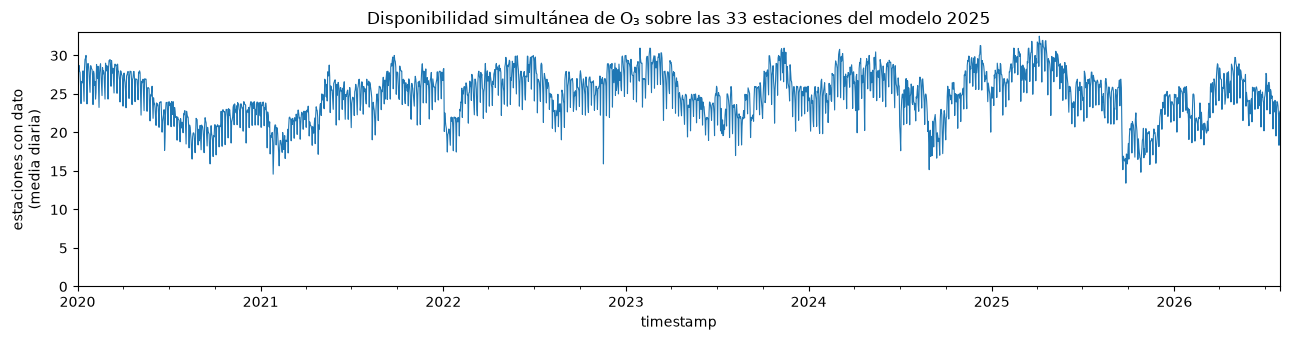

In [16]:
disp = ancho.reindex(columns=EST_2025).notna().sum(axis=1)
resumen_disp = disp.groupby(disp.index.year).describe(percentiles=[.1, .5, .9])[['mean', 'min', '10%', '50%', '90%', 'max']]
resumen_disp['horas_con_≥25'] = disp.groupby(disp.index.year).apply(lambda s: round(100 * (s >= 25).mean(), 1))
print('Estaciones (de las 33 de 2025) con dato simultáneo, por hora:')
print(resumen_disp.round(1).to_string())

fig, ax = plt.subplots(figsize=(13, 3.5))
disp.resample('D').mean().plot(ax=ax, lw=0.8)
ax.set_ylabel('estaciones con dato\n(media diaria)')
ax.set_ylim(0, 33)
ax.set_title('Disponibilidad simultánea de O₃ sobre las 33 estaciones del modelo 2025')
fig.tight_layout()
fig.savefig(IMG / 'disponibilidad_conjunta_o3.png', dpi=150)
plt.show()

## 7. Rango físico, bandas NOM-172 y contingencias (≥155 ppb)

El test de red de 2025 (21/oct–31/dic) no tenía ninguna lectura ≥155 ppb, así
que no se pudo evaluar el ocultamiento de contingencias. Aquí cuento, por año,
las lecturas horarias ≥155 ppb y los **días con al menos una estación ≥155**.
Esta cuenta es un indicador sobre datos crudos; no reproduce la regla oficial de
activación del PICA (que también considera promedios móviles y otros
contaminantes), y no se debe presentar como número de contingencias declaradas.

In [17]:
val = o3.dropna(subset=['value'])
fisico = val.groupby('anio')['value'].describe(percentiles=[.5, .9, .99])
print(fisico.round(1).to_string())

banda = pd.cut(val['value'], [-np.inf] + BANDAS_O3 + [np.inf], right=True, labels=NOMBRES_BANDA)
print('\nDistribución de bandas NOM-172 (% de lecturas válidas de la red):')
print((100 * pd.crosstab(val['anio'], banda, normalize='index')).round(3).to_string())

         count  mean   std  min   50%   90%    99%    max
anio                                                     
2020  216476.0  31.9  25.8  0.0  26.0  70.0  104.0  159.0
2021  217276.0  29.2  25.2  0.0  23.0  66.0  104.0  160.0
2022  231632.0  31.1  26.4  0.0  24.0  70.0  108.0  172.0
2023  222427.0  30.8  26.1  0.0  24.0  69.0  105.0  171.0
2024  223488.0  32.4  28.1  0.0  25.0  74.0  115.0  187.0
2025  218823.0  32.5  28.0  0.0  25.0  74.0  113.0  168.0
2026  124470.0  34.4  28.9  0.0  27.0  77.0  116.0  168.0

Distribución de bandas NOM-172 (% de lecturas válidas de la red):
value   Buena  Aceptable   Mala  Muy Mala  Ext. Mala
anio                                                
2020   83.239     13.863  2.880     0.017      0.000
2021   85.850     11.692  2.405     0.054      0.000
2022   83.621     13.204  3.064     0.111      0.000
2023   83.881     13.111  2.952     0.056      0.000
2024   82.011     13.560  4.216     0.209      0.004
2025   81.257     14.425  4.174     0.14

In [18]:
alto = val[val['value'] >= UMBRAL_CONTINGENCIA].copy()
alto['fecha'] = alto['timestamp'].dt.date
excedencias = pd.DataFrame({
    'lecturas_≥155': alto.groupby('anio').size(),
    'dias_con_alguna_estacion_≥155': alto.groupby('anio')['fecha'].nunique(),
    'estaciones_distintas': alto.groupby('anio')['station'].nunique(),
    'maximo_ppb': val.groupby('anio')['value'].max(),
}).reindex(ANIOS).fillna(0).astype(int)
print(excedencias.to_string())
excedencias.to_csv(SAL / 'excedencias_155_por_anio.csv')

print('\nMeses con días ≥155:')
print(alto.groupby([alto['anio'], alto['timestamp'].dt.month])['fecha'].nunique().unstack(fill_value=0).to_string())

      lecturas_≥155  dias_con_alguna_estacion_≥155  estaciones_distintas  maximo_ppb
anio                                                                                
2020              1                              1                     1         159
2021              4                              3                     3         160
2022             35                              7                     9         172
2023             10                              4                     6         171
2024             94                             17                    16         187
2025             25                              6                    13         168
2026             24                              9                     9         168

Meses con días ≥155:
timestamp  1   2   3   4   5   6   10  11
anio                                     
2020        0   0   0   0   0   0   0   1
2021        0   0   0   2   0   1   0   0
2022        0   0   1   0   3   1   1   1
202

In [19]:
por_est = alto.groupby(['station', 'anio'], observed=True).size().unstack(fill_value=0).reindex(columns=ANIOS, fill_value=0)
por_est = por_est[por_est.sum(axis=1) > 0].sort_values(2024, ascending=False)
print('Lecturas ≥155 ppb por estación y año:')
print(por_est.to_string())
dias = alto.groupby('fecha').agg(estaciones=('station', 'nunique'), max_ppb=('value', 'max'),
                                 hora_max=('timestamp', lambda t: t.dt.hour.mode().iat[0]))
dias.to_csv(SAL / 'dias_con_lectura_155.csv')
print('\nHora del día (0–23) de las lecturas ≥155:')
print(alto['timestamp'].dt.hour.value_counts().sort_index().to_string())

Lecturas ≥155 ppb por estación y año:
anio     2020  2021  2022  2023  2024  2025  2026
station                                          
CCA         1     2     5     0    11     0     5
TLA         0     0     0     0    11     3     0
ATI         0     0     0     0    10     0     4
CUT         0     0     0     0    10     0     0
PED         0     0     4     2    10     1     0
TLI         0     1     0     0     7     0     0
AJU         0     0     0     0     6     0     0
UAX         0     0     0     0     6     2     0
VIF         0     0     0     1     5     0     0
BJU         0     0     7     0     5     2     1
AJM         0     0     3     2     3     3     4
HGM         0     0     0     0     3     2     1
FAR         0     0     0     0     3     0     0
UIZ         0     0     1     0     2     0     0
CAM         0     0     0     0     1     1     0
MER         0     0     1     0     1     0     2
CUA         0     0     4     3     0     1     1
FAC         

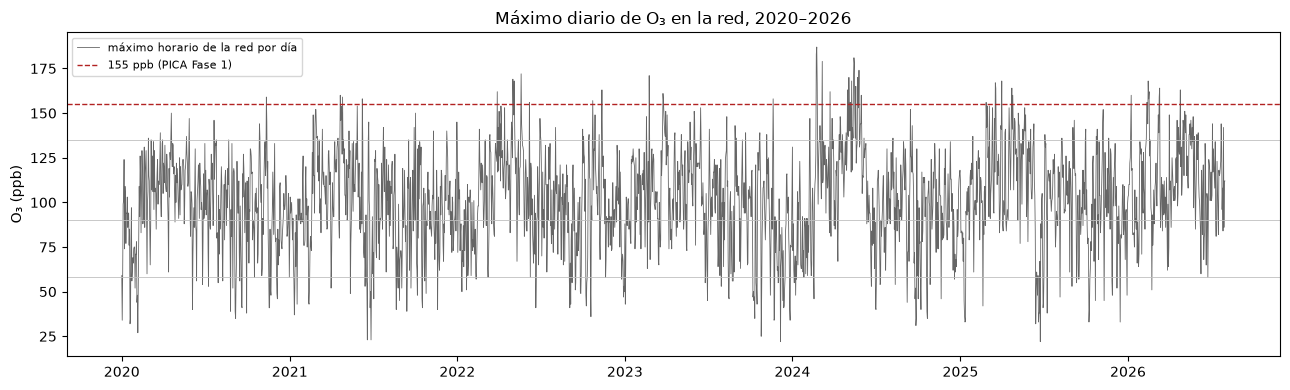

In [20]:
fig, ax = plt.subplots(figsize=(13, 4))
diario = ancho.max(axis=1).resample('D').max()
ax.plot(diario.index, diario, lw=0.6, color='0.4', label='máximo horario de la red por día')
ax.axhline(UMBRAL_CONTINGENCIA, color='firebrick', ls='--', lw=1, label='155 ppb (PICA Fase 1)')
for b in BANDAS_O3[:3]:
    ax.axhline(b, color='0.75', lw=0.6)
ax.set_ylabel('O₃ (ppb)')
ax.set_title('Máximo diario de O₃ en la red, 2020–2026')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(IMG / 'maximo_diario_red_o3.png', dpi=150)
plt.show()

## 8. Ubicación geográfica de las estaciones

Catálogo oficial descargado el 2026-10-03 de
`http://datosabiertos.aire.cdmx.gob.mx:8080/opendata/catalogos/cat_estacion.csv`
(Latin-1, primera línea de título). Se usa **sólo para describir la red**:
no entra al LSTM.

`id_station` codifica la entidad con la clave INEGI (`48409…` = Ciudad de México,
`48415…` = Estado de México), pero el catálogo la publica en notación científica
redondeada; FAR y SAC quedan como `4.848E+11` y su entidad no se puede leer de
ahí, por lo que se deja vacía en vez de adivinarla.

In [21]:
cat_path = RAIZ / 'data/reference/cat_estacion_simat.csv'
print('SHA-256 del catálogo:', sha256(cat_path.read_bytes()))
cat = pd.read_csv(cat_path, skiprows=1, encoding='latin-1')
cat['entidad'] = cat['id_station'].map(lambda x: {484090: 'CDMX', 484150: 'Edomex', 484151: 'Edomex'}.get(int(x // 1e6)))

red = cat.set_index('cve_estac').reindex(estado.index)
print('Estaciones de los xls sin registro en el catálogo:', list(red.index[red.nom_estac.isna()]) or 'ninguna')

# Distancia a CCA (haversine) — útil para leer "vecinas", que en el LSTM son todas las demás
R = 6371.0
lat, lon = np.radians(red.latitud), np.radians(red.longitud)
la0, lo0 = lat['CCA'], lon['CCA']
red['dist_cca_km'] = (2 * R * np.arcsin(np.sqrt(np.sin((lat - la0) / 2) ** 2 +
                      np.cos(la0) * np.cos(lat) * np.sin((lon - lo0) / 2) ** 2))).round(1)
red['en_matriz_2025'] = red.index.isin(EST_2025)
red['anios_operando'] = (estado == 'operó').sum(axis=1)
red['cobertura_media_%'] = cobertura.mean(axis=1).round(1)
red['nota_catalogo'] = red['obs_estac']
tabla_geo = red[['nom_estac', 'entidad', 'latitud', 'longitud', 'alt', 'dist_cca_km',
                 'en_matriz_2025', 'anios_operando', 'cobertura_media_%', 'nota_catalogo']].sort_values('dist_cca_km')
tabla_geo.to_csv(SAL / 'estaciones_geografia.csv')
print(tabla_geo.to_string())

SHA-256 del catálogo: 429ad3a2666303a457a97ed56ef6f9064187cbbf8decef27bfc6cb2f95739dd8
Estaciones de los xls sin registro en el catálogo: ninguna
                                  nom_estac entidad    latitud   longitud     alt  dist_cca_km  en_matriz_2025  anios_operando  cobertura_media_%               nota_catalogo
station                                                                                                                                                                      
CCA      Centro de Ciencias de la Atmósfera    CDMX  19.326111 -99.176111  2294.0          0.0            True               7               93.7                         NaN
PED                                Pedregal    CDMX  19.325146 -99.204136  2326.0          2.9            True               7               87.2                         NaN
COY                                Coyoacán    CDMX  19.350258 -99.157101  2260.0          3.3           False               0                0.0  Finalizó op

In [22]:
print('Contradicciones entre la nota del catálogo y los datos:')
for s, r in tabla_geo.iterrows():
    if isinstance(r.nota_catalogo, str):
        ops = [a for a in ANIOS if estado.at[s, a] == 'operó']
        print(f'  {s}: catálogo dice "{r.nota_catalogo}" | años con lecturas válidas en 2020–2026: {ops or "ninguno"}')

Contradicciones entre la nota del catálogo y los datos:
  COY: catálogo dice "Finalizó operación en 2017" | años con lecturas válidas en 2020–2026: ninguno
  BJU: catálogo dice "Finalizó operación en 2005" | años con lecturas válidas en 2020–2026: [2020, 2021, 2022, 2023, 2024, 2025, 2026]
  SJA: catálogo dice "Finalizó operación en 2017" | años con lecturas válidas en 2020–2026: ninguno


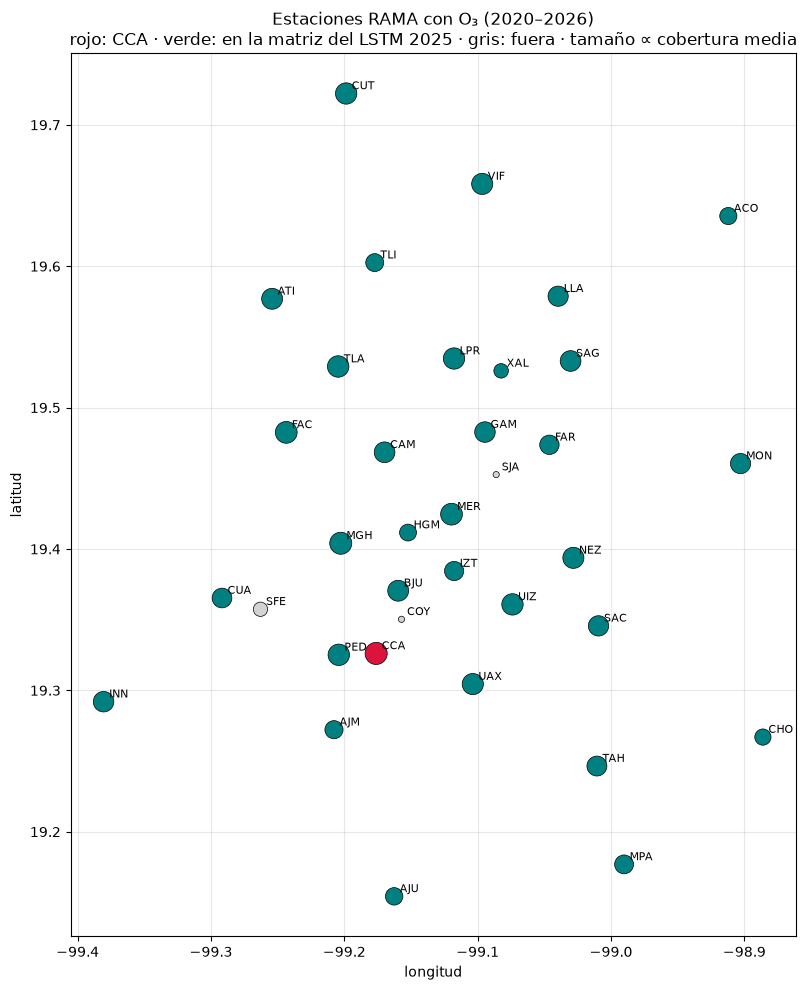

In [23]:
fig, ax = plt.subplots(figsize=(9, 10))
t = tabla_geo
colores = np.where(~t.en_matriz_2025, 'lightgray', np.where(t.index == 'CCA', 'crimson', 'teal'))
sc = ax.scatter(t.longitud, t.latitud, s=20 + 2.5 * t['cobertura_media_%'].fillna(0),
                c=colores, edgecolor='k', lw=0.5, zorder=3)
for s, r in t.iterrows():
    ax.annotate(s, (r.longitud, r.latitud), xytext=(4, 3), textcoords='offset points', fontsize=8)
ax.set_aspect(1 / np.cos(np.radians(19.4)))
ax.set_xlabel('longitud'); ax.set_ylabel('latitud')
ax.grid(alpha=0.3)
ax.set_title('Estaciones RAMA con O₃ (2020–2026)\n'
             'rojo: CCA · verde: en la matriz del LSTM 2025 · gris: fuera · tamaño ∝ cobertura media')
fig.tight_layout()
fig.savefig(IMG / 'mapa_estaciones.png', dpi=150)
plt.show()

## 9. Resumen para usar estos años con el LSTM (sin entrenar nada)

Tabla de una línea por año con lo que hay que saber antes de pasar cualquier
año por los modelos guardados de 2025.

In [24]:
resumen = pd.DataFrame({
    'horas': o3.groupby('anio')['timestamp'].nunique(),
    'renglones_ausentes': formato.query("contaminante == 'O3'").set_index('anio')['filas_faltantes'],
    'estaciones_operando': (estado == 'operó').sum(),
    'de_las_33_ausentes_todo_el_año': pd.Series({a: len(set(EST_2025) - set(estado.index[estado[a] == 'operó'])) for a in ANIOS}),
    'cobertura_mediana_33_%': cobertura.reindex(EST_2025).median().round(1),
    'cobertura_CCA_%': cobertura.loc['CCA'],
    'racha_max_CCA_h': rachas.loc['CCA'],
    'lecturas_≥155': excedencias['lecturas_≥155'],
    'dias_≥155': excedencias['dias_con_alguna_estacion_≥155'],
})
resumen.index.name = 'anio'
resumen.to_csv(SAL / 'resumen_por_anio.csv')
print(resumen.to_string())

      horas  renglones_ausentes  estaciones_operando  de_las_33_ausentes_todo_el_año  cobertura_mediana_33_%  cobertura_CCA_%  racha_max_CCA_h  lecturas_≥155  dias_≥155
anio                                                                                                                                                                    
2020   8784                   0                   31                               3                    88.3            95.26             97.0              1          1
2021   8760                   0                   31                               3                    78.9            89.49            508.0              4          3
2022   8760                   0                   32                               2                    86.6            95.23             72.0             35          7
2023   8760                   0                   33                               0                    82.1            93.11            375.0             

## 10. Conclusiones

### Los archivos y el formato

- Llegaron **7 zips × 9 contaminantes = 63 `.xls`**, sin contaminantes faltantes.
  El zip de 2025 es idéntico byte a byte a los `.xls` que ya usaba el proyecto.
  Los SHA-256 quedan en `docs/checksums_2020_2026.txt`.
- **El formato es el mismo en 2020–2026** (cierra V5 para este periodo):
  `FECHA | HORA | estaciones`, `HORA` 1..24, sin duplicados, sin celdas vacías;
  el faltante siempre es `-99`. `src/ingest/rama.py` sirve tal cual.
- **2024 tiene 2 horas sin renglón** en los 9 archivos: 17/ene 18:00 y
  06/abr 23:00. No es un `-99`, es una fila que no existe. En la rejilla
  preparada quedan como `NaN` con `origen_faltante = renglon_ausente`.
  Cualquier código que asuma 24 filas por día fallaría en 2024.
- **2026 llega hasta el 31/jul** (5,088 h). Todo lo de 2026 es parcial y cubre
  justo la temporada de ozono alto; no compararlo como si fuera un año completo.
- Sorpresas menores fuera de O₃: CO viene en decimales (ppm) y trae algunos
  negativos pequeños (−0.01 a −0.04, 2021 y 2023); NO y SO2 de 2026 traen
  tres `-1`. **O₃ no tiene ningún negativo distinto de `-99` en ningún año.**
- Algunos archivos se sustituyeron después de publicarse (2023 PM10, 2024 SO2,
  2025 NO/NOX/PM25), según su fecha dentro del zip. Por eso importan los checksums.

### El `-99` y la cobertura

- El centinela ocupa **25–32 % de las celdas de O₃** cada año; sin limpiarlo
  la media sale negativa en todos (de −2 a −11 ppb). Igual que en 2025.
- El patrón de madrugada **se repite en toda la red y en todos los años**:
  `HORA` 1–3 concentra ≈6 % de los faltantes cada una, frente a ≈3.7 % en el resto.
  Refuerza la hipótesis V11 (calibración programada), aunque sigue sin
  documentación oficial.
- **CCA sigue siendo la estación más estable**, cobertura de 89–97 %, pero
  2025 fue su mejor año, no el típico: su racha máxima fue de 17 h en 2025,
  y de **508 h (21 días) en 2021** y 375 h en 2023. La afirmación
  «CCA no tiene periodos largos fuera de operación» vale para 2025, no para la serie.

### Estaciones: el conjunto cambia cada año

- De las **33 estaciones de la matriz del LSTM 2025**, sólo en 2023 y 2025
  operaron las 33. Faltan todo el año: ACO, CHO, XAL (2020); AJM, HGM, XAL
  (2021); HGM, XAL (2022); ACO (2024); AJU, CHO, FAR (2026, hasta julio).
- SFE operó en 2020–2022 y no está entre las 33. COY y SJA no tienen ni una
  lectura en 2020–2026 (y en 2023 ni siquiera vienen como columna).
- **Consecuencia práctica para probar el LSTM:** `cargar_matriz` hace
  `dropna(axis=1, how='all')`, así que aplicada a otro año produciría otra
  lista de columnas y **otro número de características (≠66)**. Para pasar
  cualquier año por los modelos guardados hay que fijar las 33 columnas de
  2025, dejar las ausentes con máscara 0 y descartar SFE. Eso todavía no se
  ha hecho y queda como decisión para cuando se use el modelo.
- La disponibilidad simultánea mediana es de 24–27 de 33 estaciones por hora;
  el % de horas con ≥25 estaciones va de **39 % (2020) a 78 % (2022)**.
  2020 y 2021 son los años con menos contexto espacial.

### Contingencias: aquí está lo que faltaba

- El test de red de 2025 no tenía ninguna lectura ≥155 ppb. En el conjunto
  multianual hay **193 lecturas horarias ≥155 ppb en 47 días distintos**.
  **2024 es el año fuerte: 94 lecturas, 17 días, 16 estaciones, máximo de 187 ppb**,
  con 11 de esos días en mayo. Le siguen 2022 (35 lecturas en 7 días) y 2025/2026.
- Todas ocurren entre las **13 y 17 h** (pico a las 15 h) y la mayoría de
  febrero a mayo, lo que coincide con la ventana de ataque 15–17 h del notebook 01.
- CCA registra lecturas ≥155 en 2020, 2021, 2022, 2024 (11) y 2026 (5).
  Esto abre por fin la posibilidad de evaluar el **ocultamiento** de excedencias
  reales (J2, J7), siempre que el periodo de prueba no se haya usado para entrenar.
- Recordatorio: «días con alguna estación ≥155» es un conteo sobre datos crudos,
  **no** el número de contingencias declaradas por el PICA.
- La banda «Extremadamente Mala» (>175) sólo aparece en 2024 (0.004 %).

### Ubicación

- Las 36 estaciones de los `.xls` tienen coordenadas en el catálogo oficial
  (`results/inventario_multianual/estaciones_geografia.csv`, con distancia a CCA).
  La más cercana a CCA es PED (2.9 km); la más lejana de la matriz es ACO (44.2 km).
- El catálogo tiene notas desactualizadas: dice que **BJU «finalizó en 2005»**,
  pero BJU tiene lecturas válidas los 7 años. Las notas de COY/SJA («finalizó
  en 2017») sí coinciden con los datos.
- La ubicación es sólo descriptiva; no entra como característica del LSTM.

### Pendientes que deja este inventario

1. Decidir el periodo de prueba multianual para el LSTM (candidatos naturales:
   feb–may 2024 por las contingencias) **sin** usar esos datos para entrenar.
2. Construir la matriz de cada año con las 33 columnas fijas de 2025.
3. Verificar con el SIMAT la convención de `HORA` (1 → 00:00) y el motivo del
   faltante de 1–3 h (V11).
4. V10 (zonas de la ZMVM) sigue abierto; ahora hay coordenadas para resolverlo.